### 导入第三方库


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### 数据集导入与预处理

In [2]:
#Import the Dataset
df= pd.read_csv("./Phishing_Email.csv")
df.head()

,Unnamed: 0,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,1,the other side of * galicismos * * galicismo *...,Safe Email
2,2,re : equistar deal tickets are you still avail...,Safe Email
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email


In [3]:
# Check NAN values
df.isna().sum()

Unnamed: 0     0
Email Text    16
Email Type     0
dtype: int64

In [4]:
#Drop tha Na values
df = df.dropna()
print(df.isna().sum())

Unnamed: 0    0
Email Text    0
Email Type    0
dtype: int64


In [5]:
#dataset shape
df.shape

(18634, 3)

In [6]:
# Count the occurrences of each E-mail type. 
email_type_counts = df['Email Type'].value_counts()
print(email_type_counts)


Email Type
Safe Email        11322
Phishing Email     7312
Name: count, dtype: int64


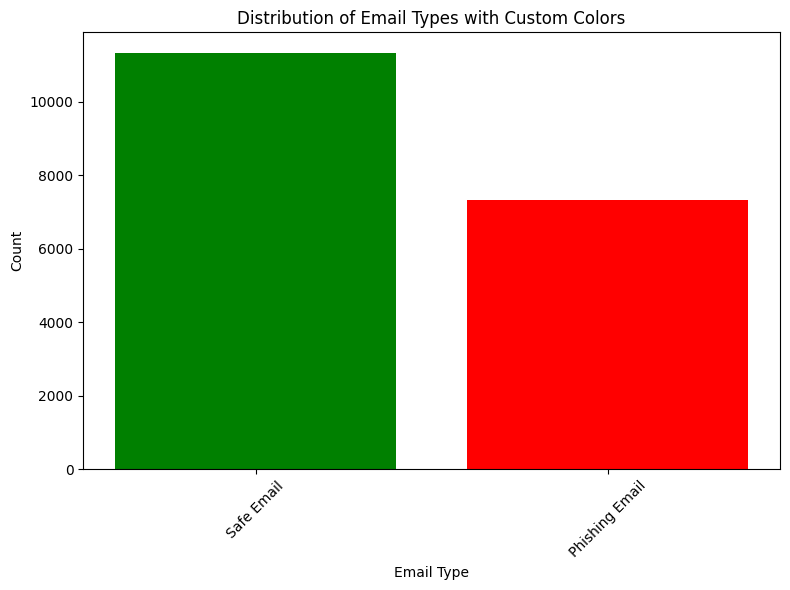

In [7]:
# Create the bar chart
# Create a list of unique email types
unique_email_types = email_type_counts.index.tolist()

# Define a custom color map 
color_map = {
    'Phishing Email': 'red',
    'Safe Email': 'green',}

# Map the colors to each email type
colors = [color_map.get(email_type, 'gray') for email_type in unique_email_types]

# Create the bar chart with custom colors
plt.figure(figsize=(8, 6))
plt.bar(unique_email_types, email_type_counts, color=colors)
plt.xlabel('Email Type')
plt.ylabel('Count')
plt.title('Distribution of Email Types with Custom Colors')
plt.xticks(rotation=45)

# Show the chart
plt.tight_layout()
plt.show()


### 处理失衡的策略

为了解决类别不平衡的问题，我们将考虑以下策略：

#### 1. 重采样技术

   a. **过采样:** 我们将通过生成合成样本（例如，使用SMOTE）来平衡类分布，从而增加少数类中的实例数量。

   b. **欠采样:** 我们可以减少多数类的实例数量来匹配少数类，有效地平衡数据集。

In [8]:
# 减少 Safe 的样本梳理
Safe_Email = df[df["Email Type"]== "Safe Email"]
Phishing_Email = df[df["Email Type"]== "Phishing Email"]
Safe_Email = Safe_Email.sample(Phishing_Email.shape[0])

In [9]:
# 检查样本数量是否一致
Safe_Email.shape,Phishing_Email.shape

((7312, 3), (7312, 3))

In [10]:
# 创建一个新的数据与平衡的 Email Type
Data= pd.concat([Safe_Email, Phishing_Email], ignore_index = True)
Data.head()

,Unnamed: 0,Email Text,Email Type
0,5231,summer opportunities hey ! does anyone know of...,Safe Email
1,16324,"alp proposal carrie , i am sending you , as pr...",Safe Email
2,6048,start date : 12 / 19 / 01 ; hourahead hour : 2...,Safe Email
3,7143,Anyone heard of this law before?> Q. Can I get...,Safe Email
4,2117,logic linguistics and information first announ...,Safe Email


### 数据集已就绪

In [11]:
# 将数据分割成特征x和因变量y的矩阵
X = Data["Email Text"].values
y = Data["Email Type"].values

In [ ]:
# 分割训练集和测试集
from sklearn.model_selection import train_test_split
X_train,x_test,y_train,y_test = train_test_split(X, y, test_size = 0.3, random_state = 0)

### 构建RandomForestClassifier模型


In [13]:
# Importing Libraries for the model ,Tfidf and Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

# define the Classifier
classifier = Pipeline([("tfidf",TfidfVectorizer() ),("classifier",RandomForestClassifier(n_estimators=10))])# add another hyperparamters as U want

In [14]:
# Trian Our model
classifier.fit(X_train,y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer()),
                ('classifier', RandomForestClassifier(n_estimators=10))])

In [15]:
# Prediction
y_pred = classifier.predict(x_test)

### 检查准确率

In [16]:
# Importing classification_report,accuracy_score,confusion_matrix
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix

In [17]:
#accuracy_score
accuracy_score(y_test,y_pred)

0.9336827711941659

In [18]:
#confusion_matrix
confusion_matrix(y_test,y_pred)

array([[2114,   84],
       [ 207, 1983]], dtype=int64)

In [20]:
#classification_report
print(classification_report(y_test,y_pred))

                precision    recall  f1-score   support

Phishing Email       0.91      0.96      0.94      2198
    Safe Email       0.96      0.91      0.93      2190

      accuracy                           0.93      4388
     macro avg       0.94      0.93      0.93      4388
  weighted avg       0.94      0.93      0.93      4388



### 构建 SVM 模型

In [21]:
# Importing SVM
from sklearn.svm import SVC

#Create the Pipeline
SVM = Pipeline([("tfidf", TfidfVectorizer()),("SVM", SVC(C = 100, gamma = "auto"))])

In [22]:
# traing the SVM model 
SVM.fit(X_train,y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer()),
                ('SVM', SVC(C=100, gamma='auto'))])

In [23]:
# y_pred. for SVM model
s_ypred = SVM.predict(x_test)

In [24]:
# check the SVM model accuracy
accuracy_score(y_test,s_ypred )

0.4990884229717411



## 结论

我们使用机器学习技术解决了网络钓鱼电子邮件检测这一重要问题。我们的目标是建立一个可靠的模型，能够根据各种特征将电子邮件准确分类为合法邮件或网络钓鱼邮件。

### 模型性能

我们实验了两种不同的机器学习模型:随机森林分类器和支持向量机(SVM)。这些模型的性能产生了截然不同的结果:

1. **随机森林分类器:**

   - 准确率: 0.931

   随机森林分类器取得了令人印象深刻的结果，准确率为0.931。它展示了正确分类合法电子邮件和网络钓鱼电子邮件的高能力。精确度、召回率和F1分数提供了模型在各种类上的性能的额外见解，这对于理解所涉及的权衡是至关重要的。

2. **支撑向量机 (SVM):**

   - 准确率: 0.499

   相比之下，支持向量机(SVM)表现出明显较低的性能，准确率仅为0.499。这表明SVM模型很难有效区分我们数据集中的合法电子邮件和网络钓鱼电子邮件。

### 模型可解释性

理解随机森林分类器优于SVM分类器的原因对于进一步改进模型至关重要。造成这种差异的潜在因素包括**特征选择、模型复杂性和超参数调整**。对特征重要性和模型决策过程的更深入研究可以揭示有助于模型高精度的关键特征。

### 未来方向

虽然随机森林分类器显示出有希望的结果，但仍有改进和进一步探索的空间:

1. **特征工程:** 调查和设计更多相关功能，以增强模型性能和电子邮件类型之间的区分。

2. **超参数调谐:** 微调两个模型的超参数，以最大化其性能。

3. **集成技术:** 探索集成技术，如bagging和boosting，以提高模型的鲁棒性。

4. **数据扩充:** 尝试使用数据扩充技术来生成更多的训练样本，如果存在类别不平衡，则有可能解决这一问题。

5. **深度学习:** 考虑深度学习方法，如神经网络，它已经在类似的任务中显示出成功。

6. **可解释性:** 实现模型可解释性技术，以理解模型预测背后的基本原理，增加信任和可解释性。

总之，虽然随机森林分类器展示了检测网络钓鱼电子邮件的强大潜力，但SVM模型在准确性方面有所欠缺。在持续有效地打击电子邮件网络钓鱼威胁的努力中，该项目是更高级调查和增强的起点。

In [25]:
# save model
import pickle
# 保存
with open('phishing_text_model.pkl', 'wb') as f:
    pickle.dump(classifier, f)

In [43]:
# load model to test
with open('phishing_text_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

text = [
    "re : equistar deal tickets are you still available to assist robert with entering the new deal tickets for equistar ? after talking with bryan hull and anita luong , kyle and i decided we only need 1 additional sale ticket and 1 additional buyback ticket set up . - - - - - - - - - - - - - - - - - - - - - - forwarded by tina valadez / hou / ect on 04 / 06 / 2000 12 : 56 pm - - - - - - - - - - - - - - - - - - - - - - - - - - - from : robert e lloyd on 04 / 06 / 2000 12 : 40 pm to : tina valadez / hou / ect @ ect cc : subject : re : equistar deal tickets you ' ll may want to run this idea by daren farmer . i don ' t normally add tickets into sitara . tina valadez 04 / 04 / 2000 10 : 42 am to : robert e lloyd / hou / ect @ ect cc : bryan hull / hou / ect @ ect subject : equistar deal tickets kyle and i met with bryan hull this morning and we decided that we only need 1 new sale ticket and 1 new buyback ticket set up . the time period for both tickets should be july 1999 - forward . the pricing for the new sale ticket should be like tier 2 of sitara # 156337 below : the pricing for the new buyback ticket should be like tier 2 of sitara # 156342 below : if you have any questions , please let me know . thanks , tina valadez 3 - 7548",
    '''
Hello I am your hot lil horny toy.
    I am the one you dream About,
    I am a very open minded person,
    Love to talk about and any subject.
    Fantasy is my way of life, 
    Ultimate in sex play.     Ummmmmmmmmmmmmm
     I am Wet and ready for you.     It is not your looks but your imagination that matters most,
     With My sexy voice I can make your dream come true...
  
     Hurry Up! call me let me Cummmmm for you..........................
TOLL-FREE:             1-877-451-TEEN (1-877-451-8336)For phone billing:     1-900-993-2582
-- 
_______________________________________________
Sign-up for your own FREE Personalized E-mail at Mail.com
http://www.mail.com/?sr=signup''',
'''On Sun, Aug 11, 2002 at 11:17:47AM +0100, wintermute mentioned:
> > The impression I get from reading lkml the odd time is
> > that IDE has gone downhill since Andre Hedrick was 
> > effectively removed as maintainer. Martin Dalecki seems
> > to have been unable to further development without 
> > much breakage. 
> 
> Hmm... begs the question, why remove Handrick?
> If it ain't broke, don't fix it. See, the IDE subsystem is like the One Ring. It's kludginess, due to
having to support hundreds of dodgy chipsets & drives means that it is
inherintly evil. A few months of looking at the code can turn you sour.
Years of looking at it will turn you into an arsehole. They haven't found a hobbit that can code, so mortal humans have to
suffice. Kate
-- 
Irish Linux Users' Group: ilug@linux.ie
http://www.linux.ie/mailman/listinfo/ilug for (un)subscription information.
List maintainer: listmaster@linux.ie
''',
'''Just call Mommy Not important I want to know was this bad night I dont know Okay Love you''',
'''This is your last chance to WIN cash. Click this link''',
]
predictions = loaded_model.predict(text)
# 输出置信度
# predictions = loaded_model.predict_proba(text)
print(predictions)

['Safe Email' 'Phishing Email' 'Safe Email' 'Safe Email' 'Phishing Email']
